<a href="https://colab.research.google.com/github/bijaybenny/Epochs-Data-Science/blob/main/Day-3/task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
from google.colab import files

uploaded = files.upload()

Saving used_cars.csv to used_cars.csv


In [6]:
df = pd.read_csv("used_cars.csv")

In [7]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [9]:
df.shape

(4009, 12)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [11]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [12]:
df.describe(include='object')

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [13]:
numerical = df.select_dtypes(include=np.number)

categorical = df.select_dtypes(exclude=np.number)

print(numerical.columns)

print(categorical.columns)

Index(['model_year'], dtype='object')
Index(['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission',
       'ext_col', 'int_col', 'accident', 'clean_title', 'price'],
      dtype='object')


In [14]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


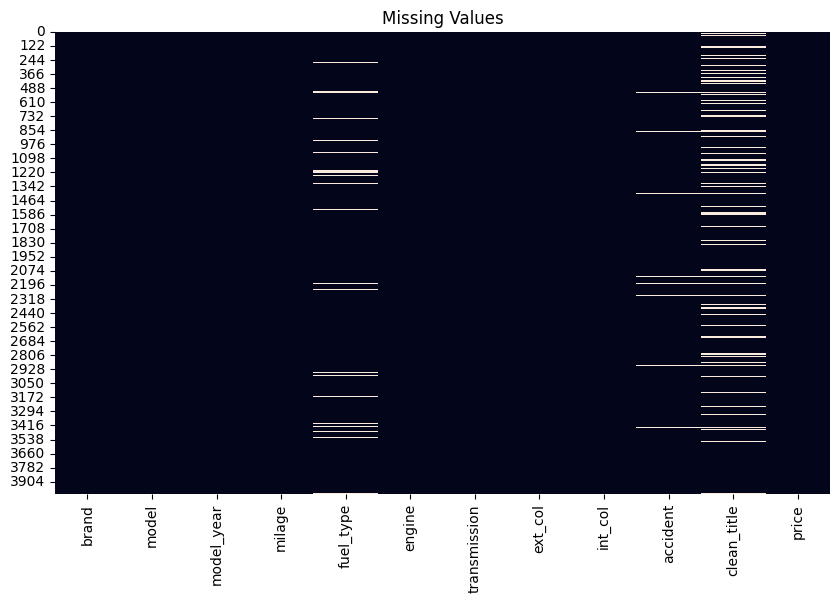

In [15]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),cbar=False)

plt.title("Missing Values")

plt.show()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
for col in categorical.columns:
    print(col)
    print(df[col].nunique())
    print(df[col].value_counts().head())
    print("-"*50)

brand
57
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Name: count, dtype: int64
--------------------------------------------------
model
1898
model
M3 Base          30
F-150 XLT        24
Corvette Base    22
1500 Laramie     18
Camaro 2SS       17
Name: count, dtype: int64
--------------------------------------------------
milage
2818
milage
110,000 mi.    16
45,000 mi.     15
120,000 mi.    13
55,000 mi.     13
54,000 mi.     12
Name: count, dtype: int64
--------------------------------------------------
fuel_type
7
fuel_type
Gasoline         3309
Hybrid            194
E85 Flex Fuel     139
Diesel            116
–                  45
Name: count, dtype: int64
--------------------------------------------------
engine
1146
engine
2.0L I4 16V GDI DOHC Turbo                               52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             47
–              

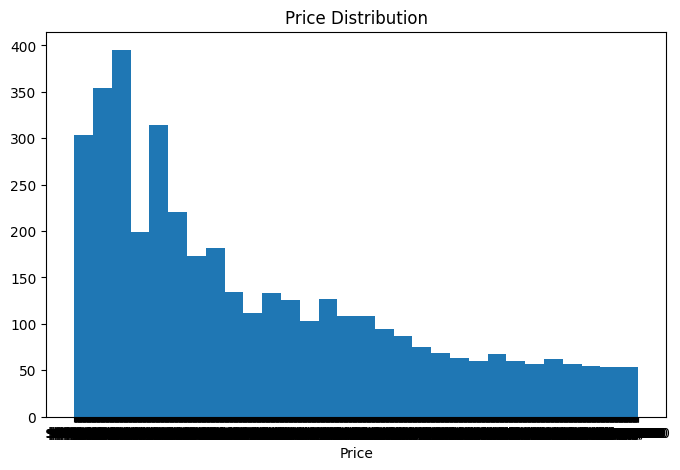

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["price"],bins=30)

plt.title("Price Distribution")

plt.xlabel("Price")

plt.show()

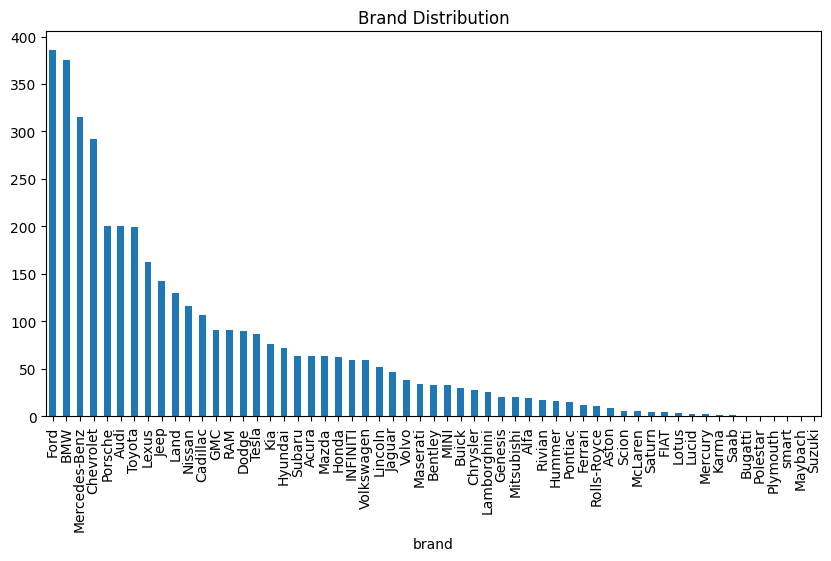

In [19]:
plt.figure(figsize=(10,5))

df["brand"].value_counts().plot(kind="bar")

plt.title("Brand Distribution")

plt.show()

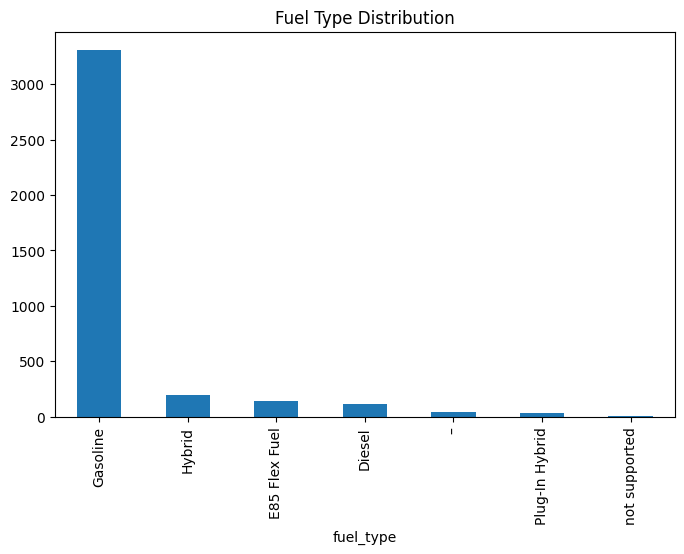

In [20]:
plt.figure(figsize=(8,5))

df["fuel_type"].value_counts().plot(kind="bar")

plt.title("Fuel Type Distribution")

plt.show()

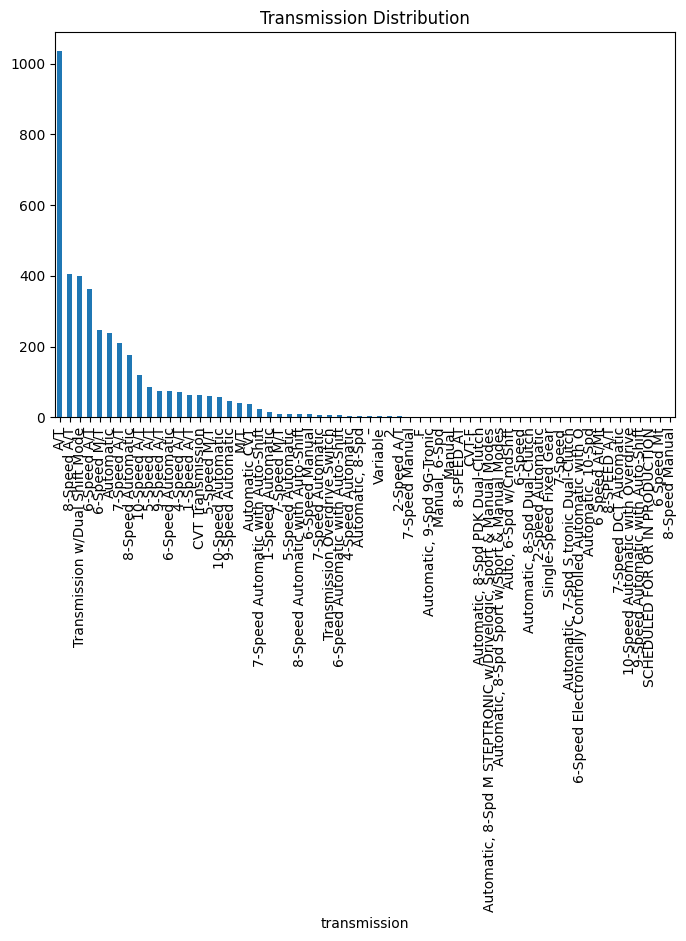

In [21]:
plt.figure(figsize=(8,5))

df["transmission"].value_counts().plot(kind="bar")

plt.title("Transmission Distribution")

plt.show()

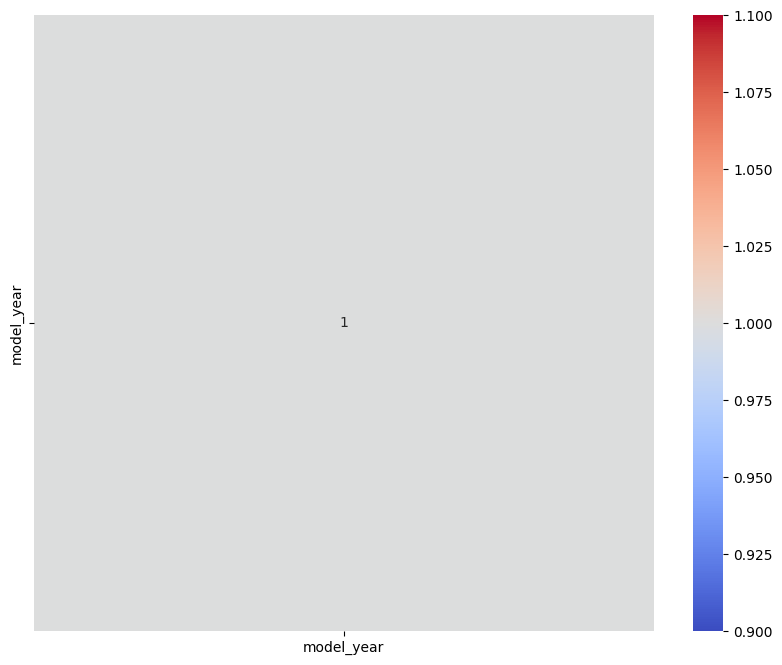

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

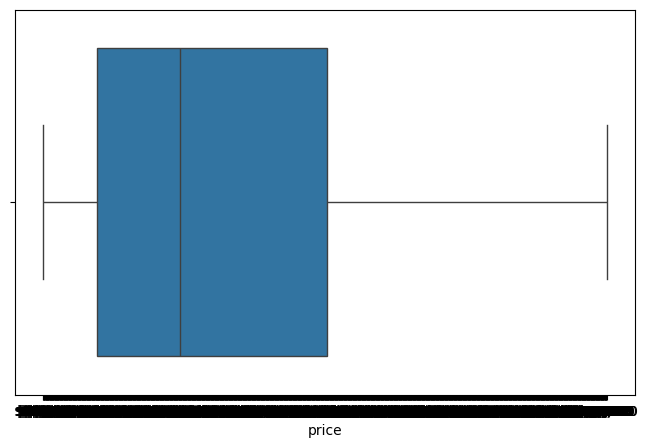

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["price"])

plt.show()

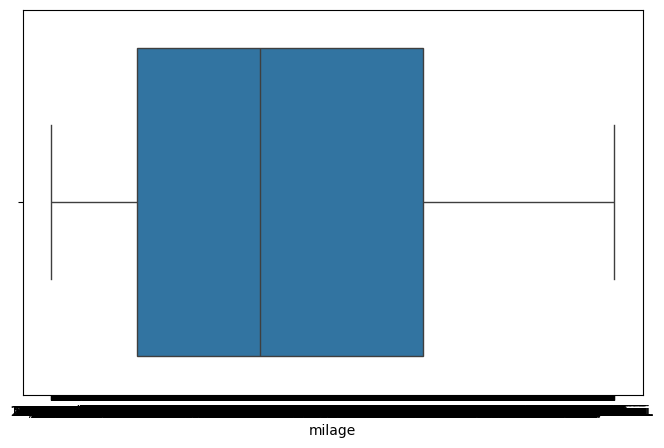

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["milage"])

plt.show()

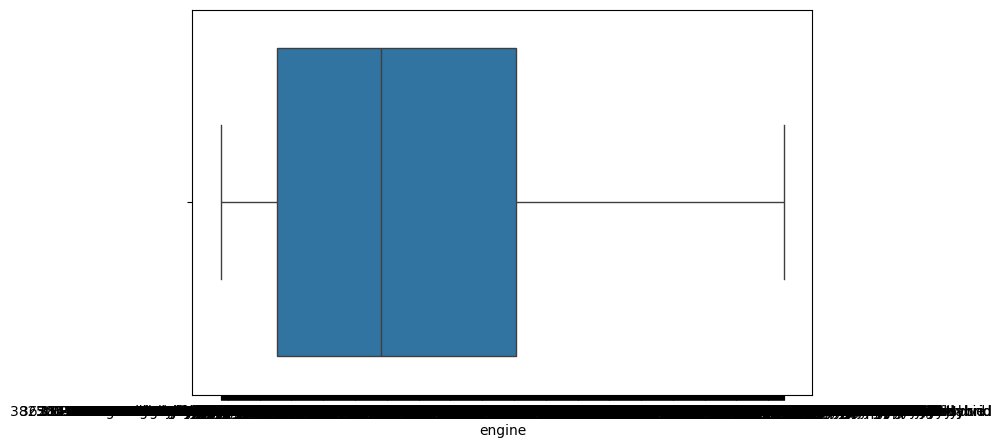

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["engine"])

plt.show()

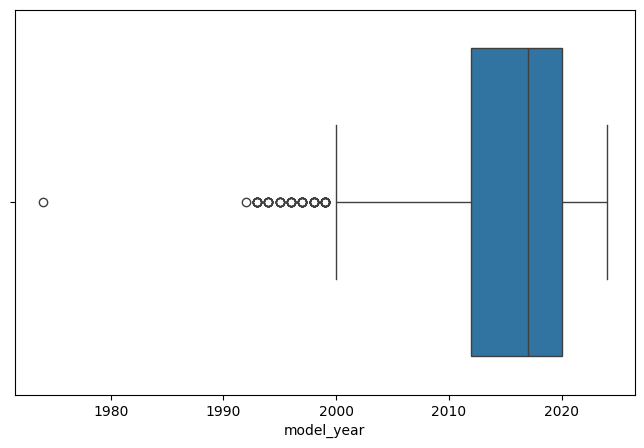

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["model_year"])

plt.show()

In [29]:
df = df.drop_duplicates()

In [30]:
for col in numerical.columns:
    df[col].fillna(df[col].median(),inplace=True)

/tmp/ipykernel_737/3468671057.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [31]:
for col in categorical.columns:
    df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipykernel_737/3342957546.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [33]:
df.dtypes


,0
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


In [36]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [37]:
df["price"].dtype

dtype('int64')

In [38]:
df["milage"] = (
    df["milage"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r'(\d+)')[0]
)

df["milage"] = pd.to_numeric(df["milage"], errors="coerce")

In [39]:
df["milage"].dtype

dtype('int64')

In [40]:
df["engine"] = (
    df["engine"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

df["engine"] = pd.to_numeric(df["engine"], errors="coerce")

In [41]:
df.dtypes

,0
brand,object
model,object
model_year,int64
milage,int64
fuel_type,object
engine,float64
transmission,object
ext_col,object
int_col,object
accident,object


In [42]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)]

In [43]:
Q1 = df["milage"].quantile(0.25)
Q3 = df["milage"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["milage"] >= lower) & (df["milage"] <= upper)]

In [44]:
Q1 = df["engine"].quantile(0.25)
Q3 = df["engine"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["engine"] >= lower) & (df["engine"] <= upper)]

In [45]:
df[["engine", "milage", "price"]].head(10)

,engine,milage,price
0,300.0,51000,10300
1,3.8,34742,38005
2,3.5,22372,54598
3,354.0,88900,15500
4,2.0,9835,34999
5,2.4,136397,14798
6,292.0,84000,31000
8,311.0,23436,41927
9,534.0,34000,69950
10,6.0,27608,73897


In [46]:
CURRENT_YEAR = 2026

df["vehicle_age"] = CURRENT_YEAR - df["model_year"]

In [47]:
df["price_per_mile"] = df["price"] / (df["milage"] + 1)

In [48]:
luxury_brands = [
    "BMW",
    "Mercedes-Benz",
    "Audi",
    "Lexus",
    "Porsche",
    "Land",
    "Jaguar",
    "Maserati",
    "Bentley",
    "Tesla"
]

df["is_luxury"] = df["brand"].isin(luxury_brands).astype(int)

In [49]:
df["high_mileage"] = (df["milage"] > 100000).astype(int)

In [50]:
df["age_group"] = pd.cut(
    df["vehicle_age"],
    bins=[0,5,10,20,100],
    labels=["New","Moderate","Old","Very Old"]
)

In [51]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,vehicle_age,price_per_mile,is_luxury,high_mileage,age_group
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,0.201957,0,0,Old
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,5,1.093889,0,0,New
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5,Automatic,Blue,Black,None reported,Yes,54598,4,2.440352,1,0,New
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0,7-Speed A/T,Black,Black,None reported,Yes,15500,11,0.174351,0,0,Old
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,34999,5,3.558255,1,0,New


In [52]:
df.to_csv("cleaned_used_cars.csv", index=False)

In [53]:
from google.colab import files

files.download("cleaned_used_cars.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>